<a href="https://colab.research.google.com/github/mohanvidushi50/Character_analysis/blob/main/nltk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# nltk       ->text processing
# matplotlib -> charts and plots
# wordcloud  -> word-cloud visualizations
!pip install nltk matplotlib wordcloud -q

import nltk
#for chunking
nltk.download("punkt")
nltk.download("punkt_tab")

#for stopwords
nltk.download("stopwords")

#for meanings (WordNet)
nltk.download("wordnet")
nltk.download("omw-1.4")

#for POS tagging
nltk.download("averaged_perceptron_tagger") # Added for pos_tag
nltk.download("averaged_perceptron_tagger_eng") # Added for pos_tag
#for NER
nltk.download("maxent_ne_chunker")
nltk.download("maxent_ne_chunker_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxen

True

In [ ]:
from google.colab import files #uploading files
uploaded=files.upload()
filename=list(uploaded.keys())[0]

with open(filename,'r',encoding='utf-8')as f:
  text=f.read()
print(len(text),"characters read")

Saving the-palace-of-illusions-com-v4-0.txt to the-palace-of-illusions-com-v4-0.txt
678023 characters read


In [ ]:
import re

#matching pattern to count chapters
pattern = r'(?m)^\s*\d+\s*$'

splits = re.split(pattern, text)

# splits[0] is the text before Chapter 1 so we skip it
chapters = [part.strip() for part in splits[1:] if len(part.strip()) > 200]

print(len(chapters), "chapters found")
print(chapters[0][:300])


43 chapters found
fire




                               Through the long, lonely years of my
                               childhood, when my father’s palace
                    �          seemed to tighten its grip around me until
I couldn’t breathe, I would go to my nurse and ask for a story. And
though she knew


In [ ]:
import string
from nltk import sent_tokenize,word_tokenize
from nltk.corpus import stopwords
import re

#making a list of all stop words
stop_words=set(stopwords.words("english"))

def preprocess(text):
    sentences = sent_tokenize(text)
    words = re.findall(r"[a-zA-Z]+", text.lower())
    words = [word for word in words if word not in stop_words]
    return sentences, words

sentences, words = preprocess(chapters[0])
print(len(sentences))
print(words[:15])

137
['fire', 'long', 'lonely', 'years', 'childhood', 'father', 'palace', 'seemed', 'tighten', 'grip', 'around', 'breathe', 'would', 'go', 'nurse']


In [ ]:
from nltk.stem import PorterStemmer,WordNetLemmatizer
porter=PorterStemmer()
lemmatizer=WordNetLemmatizer()

for w in words[:15]:
   stemmed =porter.stem(w)#gives steed word
   lemmatized=lemmatizer.lemmatize(w)#lemmatized form
   print(w,stemmed,lemmatized)# word stemmed lematized

fire fire fire
long long long
lonely lone lonely
years year year
childhood childhood childhood
father father father
palace palac palace
seemed seem seemed
tighten tighten tighten
grip grip grip
around around around
breathe breath breathe
would would would
go go go
nurse nurs nurse


In [ ]:
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 122.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")#we are laoding the english modle

In [ ]:
from collections import Counter

def extract_people_spacy(text):
    doc = nlp(text)
    people = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
    return people

all_people = []
for i, chapter in enumerate(chapters):
    print(f"Processing chapter {i+1}...")
    all_people.extend(extract_people_spacy(chapter))

character_count = Counter(all_people)
print(character_count.most_common(30))

Processing chapter 1...
Processing chapter 2...
Processing chapter 3...
Processing chapter 4...
Processing chapter 5...
Processing chapter 6...
Processing chapter 7...
Processing chapter 8...
Processing chapter 9...
Processing chapter 10...
Processing chapter 11...
Processing chapter 12...
Processing chapter 13...
Processing chapter 14...
Processing chapter 15...
Processing chapter 16...
Processing chapter 17...
Processing chapter 18...
Processing chapter 19...
Processing chapter 20...
Processing chapter 21...
Processing chapter 22...
Processing chapter 23...
Processing chapter 24...
Processing chapter 25...
Processing chapter 26...
Processing chapter 27...
Processing chapter 28...
Processing chapter 29...
Processing chapter 30...
Processing chapter 31...
Processing chapter 32...
Processing chapter 33...
Processing chapter 34...
Processing chapter 35...
Processing chapter 36...
Processing chapter 37...
Processing chapter 38...
Processing chapter 39...
Processing chapter 40...
Processin

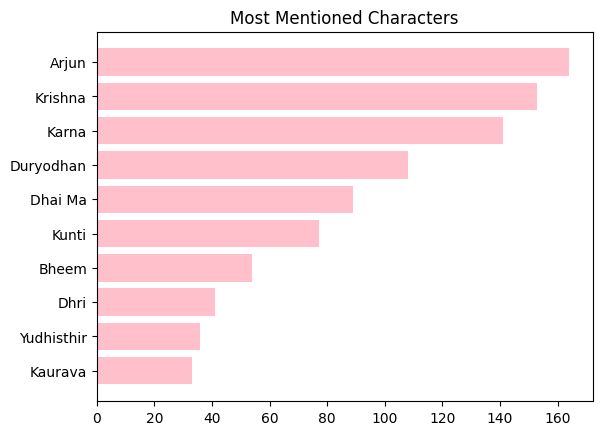

In [ ]:
import matplotlib.pyplot as plt

top_chars = character_count.most_common(10)

names = [item[0] for item in top_chars]
counts = [item[1] for item in top_chars]

plt.barh(names[::-1], counts[::-1], color='pink')
plt.title("Most Mentioned Characters")
plt.show()

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')#dataset havig alredy predefined words and their snetimment
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
test_score = sia.polarity_scores(chapters[0])
print(test_score)

{'neg': 0.081, 'neu': 0.803, 'pos': 0.116, 'compound': 0.9981}


In [ ]:
chapter_scores = []

for chapter in chapters:
    score = sia.polarity_scores(chapter)['compound']
    chapter_scores.append(score)
print (chapter_scores)
print (len(chapter_scores))

[0.9981, 0.9992, 0.9995, 0.9971, 0.9941, 0.9968, 0.9989, 0.9867, -0.9961, -0.989, 0.998, 0.9975, -0.4873, -0.9114, -0.4172, 0.9988, 0.9991, 0.9995, 0.9998, 0.9965, 0.9948, 0.9881, 0.9967, 0.9994, -0.9948, -0.9964, 0.999, 0.9937, 0.9991, 0.9966, 0.9985, 0.8902, -0.9986, -0.9993, -0.9999, -0.9958, -0.9997, -0.9999, -0.995, -0.9738, -0.9996, 0.9989, 0.9991]
43


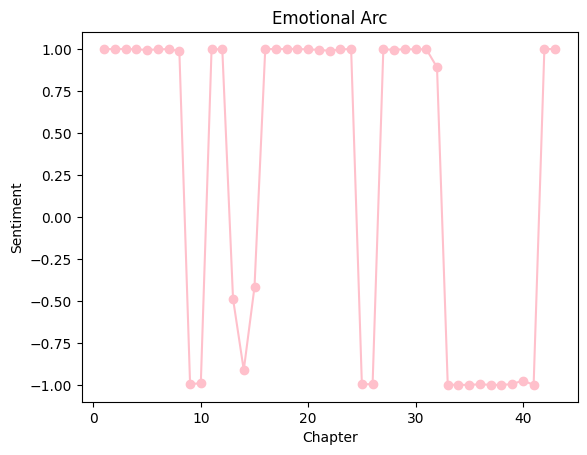

In [ ]:
plt.plot(range(1, len(chapter_scores)+1), chapter_scores, marker='o')
plt.xlabel("Chapter")
plt.ylabel("Sentiment")
plt.title("Emotional Arc")
plt.show()

In [ ]:
from nltk import sent_tokenize
from collections import Counter
import re
def character_profile(name, chapters):
    relevant_sentences = []
    for chapter_text in chapters:
        for sent in sent_tokenize(chapter_text):
            if name.lower() in sent.lower():
                relevant_sentences.append(sent)

    # Sentiment calculation
    if relevant_sentences:
        scores = [sia.polarity_scores(s)['compound'] for s in relevant_sentences]
        avg_sentiment = sum(scores) / len(scores)
    else:
        avg_sentiment = 0.0

    # Theme detection
    themes = {
        "Power": [
            "power", "king", "queen", "throne", "kingdom",
            "rule", "crown", "authority"
        ],

        "Destiny": [
            "destiny", "fate", "future", "prophecy",
            "destined", "fortune"
        ],

        "Honor": [
            "honor", "honour", "respect", "dignity",
            "shame", "pride", "glory"
        ],

        "Revenge": [
            "revenge", "vengeance", "hate",
            "anger", "wrath", "curse", "destroy"
        ],

        "Love": [
            "love", "beloved", "marriage",
            "desire", "affection", "heart"
        ],

        "War": [
            "war", "battle", "weapon",
            "fight", "army", "victory",
            "defeat", "arrow", "sword"
        ],

        "Wisdom": [
            "wisdom", "knowledge", "truth",
            "learn", "teacher", "understand",
            "guide"
        ],

        "Compassion": [
            "kind", "care", "forgive",
            "help", "protect", "gentle",
            "mercy"
        ]
    }

    theme_scores = Counter()

    for sentence in relevant_sentences:
        words = re.findall(r"[a-zA-Z]+", sentence.lower())

        for theme, keywords in themes.items():
            for word in words:
                if word in keywords:
                    theme_scores[theme] += 1

    # Top associated words
    all_words = []
    for s in relevant_sentences:
        clean = re.findall(r"[a-zA-Z]+", s.lower())
        all_words.extend([w for w in clean if w not in stop_words])

    top_words = Counter(all_words).most_common(5)

    # Overall mood
    mood = (
        "generally positive"
        if avg_sentiment > 0.1
        else "generally negative"
        if avg_sentiment < -0.1
        else "emotionally neutral"
    )

    print(f"\n{'='*40}")
    print(f"Character: {name}")
    print(f"{'='*40}")

    print(f"Mentions: {len(relevant_sentences)}")
    print(f"Average Sentiment: {avg_sentiment:.2f} ({mood})")

    print("\nDominant Themes:")
    if theme_scores:
        for theme, score in theme_scores.most_common(3):
            print(f"• {theme}: {score}")
    else:
        print("No dominant themes detected.")

for char_name, _ in character_count.most_common(3):
    character_profile(char_name, chapters)

    character_profile("Draupadi", chapters)


Character: Arjun
Mentions: 242
Average Sentiment: -0.02 (emotionally neutral)

Dominant Themes:
• War: 34
• Power: 13
• Love: 12

Character: Draupadi
Mentions: 21
Average Sentiment: -0.08 (emotionally neutral)

Dominant Themes:
• Revenge: 3
• Power: 3
• War: 1

Character: Krishna
Mentions: 252
Average Sentiment: 0.05 (emotionally neutral)

Dominant Themes:
• War: 13
• Compassion: 12
• Power: 10

Character: Draupadi
Mentions: 21
Average Sentiment: -0.08 (emotionally neutral)

Dominant Themes:
• Revenge: 3
• Power: 3
• War: 1

Character: Karna
Mentions: 241
Average Sentiment: -0.04 (emotionally neutral)

Dominant Themes:
• War: 19
• Love: 13
• Power: 9

Character: Draupadi
Mentions: 21
Average Sentiment: -0.08 (emotionally neutral)

Dominant Themes:
• Revenge: 3
• Power: 3
• War: 1
